In [1]:
# Call the important Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('healthcare_dataset1.csv')
data.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


Test Results
Abnormal        18627
Normal          18517
Inconclusive    18356
Name: count, dtype: int64


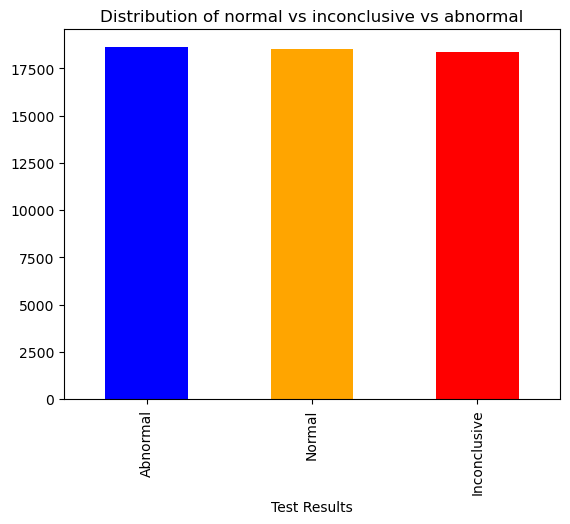

In [3]:
# check if the outcome feature is balanbced 
imbalance_check = data['Test Results'].value_counts()
print(imbalance_check)

# Optional: Visualize the imbalance
import matplotlib.pyplot as plt
data['Test Results'].value_counts().plot(kind='bar', color=['blue', 'orange', "red"])
plt.title('Distribution of normal vs inconclusive vs abnormal')
plt.show()

In [4]:
# data preprocessing and visualization 
data.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(534)

In [6]:
data.drop_duplicates(inplace=True)

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.describe()

,Age,Billing Amount,Room Number
count,54966.000000,54966.000000,54966.000000
mean,51.535185,25544.306284,301.124404
std,19.605661,14208.409711,115.223143
min,13.000000,-2008.492140,101.000000
25%,35.000000,13243.718641,202.000000
50%,52.000000,25542.749145,302.000000
75%,68.000000,37819.858159,401.000000
max,89.000000,52764.276736,500.000000


<Axes: ylabel='count'>

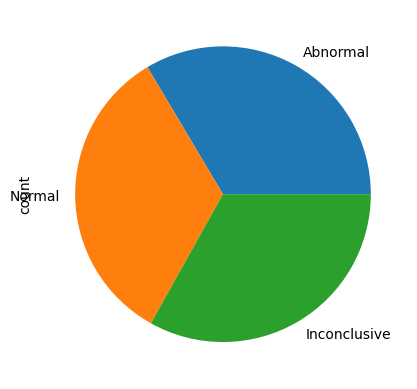

In [9]:
data["Test Results"].value_counts().plot(kind="pie")

<Axes: xlabel='Admission Type'>

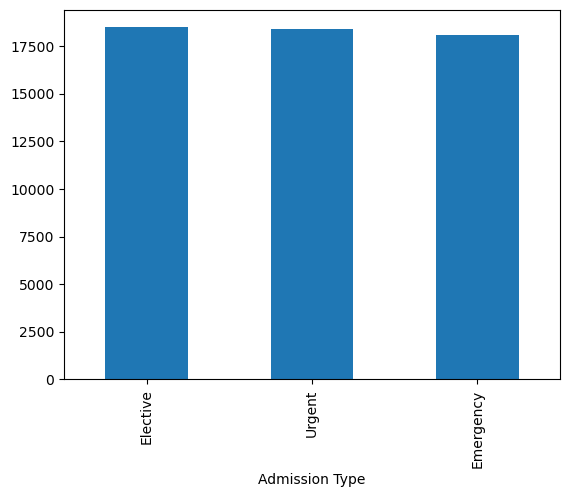

In [10]:
data["Admission Type"].value_counts().plot(kind="bar")

<Axes: ylabel='Billing Amount'>

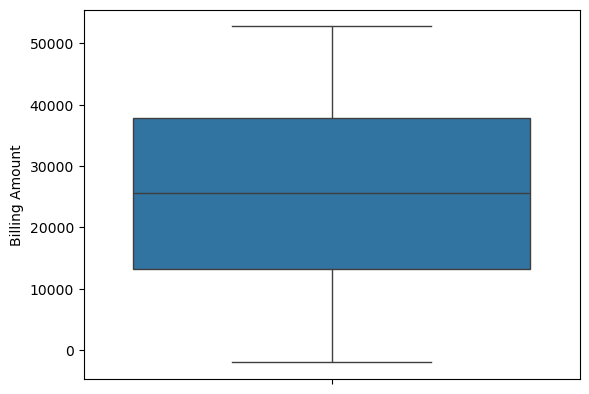

In [11]:
import seaborn as sns
sns.boxplot(data['Billing Amount'])

In [12]:
data= data.drop(columns= ['Name', "Date of Admission", 'Insurance Provider', 'Billing Amount', "Discharge Date", "Doctor", 'Room Number'])
data.head()

,Age,Gender,Blood Type,Medical Condition,Hospital,Admission Type,Medication,Test Results
0,30,Male,B-,Cancer,Sons and Miller,Urgent,Paracetamol,Normal
1,62,Male,A+,Obesity,Kim Inc,Emergency,Ibuprofen,Inconclusive
2,76,Female,A-,Obesity,Cook PLC,Emergency,Aspirin,Normal
3,28,Female,O+,Diabetes,"Hernandez Rogers and Vang,",Elective,Ibuprofen,Abnormal
4,43,Female,AB+,Cancer,White-White,Urgent,Penicillin,Abnormal


In [13]:
Xx= data.drop(columns=["Test Results"])
Xx.head()

,Age,Gender,Blood Type,Medical Condition,Hospital,Admission Type,Medication
0,30,Male,B-,Cancer,Sons and Miller,Urgent,Paracetamol
1,62,Male,A+,Obesity,Kim Inc,Emergency,Ibuprofen
2,76,Female,A-,Obesity,Cook PLC,Emergency,Aspirin
3,28,Female,O+,Diabetes,"Hernandez Rogers and Vang,",Elective,Ibuprofen
4,43,Female,AB+,Cancer,White-White,Urgent,Penicillin


In [14]:
y= data["Test Results"]
y.head()

0          Normal
1    Inconclusive
2          Normal
3        Abnormal
4        Abnormal
Name: Test Results, dtype: object

In [15]:
categorical_columns = [
    "Gender", "Blood Type", "Medical Condition", "Hospital", "Admission Type", "Medication"]

numerical_columns = ["Age"]

# Transformer
categorical_Transformer = OneHotEncoder(handle_unknown='ignore')
numerical_Transformer = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_Transformer, numerical_columns),
    ("cat", categorical_Transformer, categorical_columns)
])
X= preprocessor.fit_transform(Xx)

In [16]:
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42)
print("X_train shape: {}".format(X_train.shape)) 
print("X_test shape: {}".format(X_test.shape))

print("y_train shape: {}".format(y_train.shape))
print("y_test shape: {}".format(y_test.shape))

X_train shape: (43972, 39901)
X_test shape: (10994, 39901)
y_train shape: (43972,)
y_test shape: (10994,)


In [ ]:
# Create a Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # You can c

# Train the model
rf_classifier.fit(X_train, y_train)


In [ ]:
# Make predictions on the test set
y_pred = rf_classifier.predict(x_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


In [ ]:

# Get feature importances
importances = rf_classifier.feature_importances_

# Create a dictionary of feature names and their importances
feature_importances = dict(zip(X.columns, importances))

# Sort features by importance in descending order
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

# Print feature importances
print("Feature Importances:")
for feature, importance in sorted_feature_importances.items():
    print(f"{feature}: {importance}")


In [ ]:
import numpy as np
# Plotting feature importances with different colors

plt.figure(figsize=(10, 6))

# Generate a list of colors (you can customize these)
colors = plt.cm.viridis(np.linspace(0, 1, len(sorted_feature_importances)))

plt.barh(list(sorted_feature_importances.keys()), 
         list(sorted_feature_importances.values()), 
         color=colors)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model with the appropriate 'average' setting
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')  # or 'micro' or 'weighted'
recall = recall_score(y_test, y_pred, average='macro')        # or 'micro' or 'weighted'
f1 = f1_score(y_test, y_pred, average='macro')               # or 'micro' or 'weighted'

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}")

import numpy as np

# Create a bar plot for the metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [accuracy, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1.1)  # Set y-axis limit to accommodate values between 0 and 1
plt.ylabel("Score")

In [ ]:
plt.title("Model Evaluation Metrics")
plt.show()